# Portfolio Optimization — Monte Carlo · S&P 500

Cuaderno **referencial**: optimización Markowitz (Media-Varianza) mediante Monte Carlo vectorizado.  
Retornos simples · Anualización geométrica · Dos horizontes (63d trimestral / 252d anual) · Rf dinámica.

In [1]:
import yfinance as yf
import pandas as pd
import requests
from io import StringIO
from datetime import datetime, timedelta
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import shapiro, jarque_bera, norm
from scipy.optimize import minimize
import math

## Tasa Libre de Riesgo (Rf)

Para un inversor en USD (vía IBKR → S&P 500), el benchmark sin riesgo es el **T-Bill 3M de EEUU** (`^IRX`):  
- Duración ultracorta → sin riesgo de tipo de interés ni de crédito soberano material  
- Refleja el coste de oportunidad real: lo que obtienes sin asumir riesgo de mercado  
- Se descarga automáticamente en cada ejecución — siempre actualizada

In [2]:
try:
    _tbill = yf.download('^IRX', period='5d', auto_adjust=False, progress=False)
    # yfinance devuelve MultiIndex aunque sea un solo ticker — squeeze() lo colapsa a Series
    RF_ANNUAL = float(_tbill['Close'].squeeze().dropna().iloc[-1]) / 100
    print(f'Rf dinamica (T-Bill 3M):  {RF_ANNUAL*100:.2f}% anual')
except Exception:
    RF_ANNUAL = 0.043
    print(f'Rf estatica (fallback):   {RF_ANNUAL*100:.2f}% anual')

Rf dinamica (T-Bill 3M):  3.63% anual


## 1. Descarga de datos — S&P 500

Composición actual del índice vía Wikipedia (dinámica, siempre actualizada). 3 años de precios ajustados.  

**Por qué retornos simples y no log-retornos:**  
- Log-retorno: `ln(Pt/Pt-1)` — aditivo en el tiempo, pero **no aditivo entre activos**. El retorno de una cartera NO es `Σ wᵢ·ln(rᵢ)`.  
- Retorno simple: `(Pt−Pt-1)/Pt-1` — **exactamente aditivo entre activos**: `R_cartera = Σ wᵢ·Rᵢ`. Fundamental para la optimización de pesos.  
- Para retornos diarios pequeños la diferencia numérica es despreciable, pero la propiedad de agregación cross-seccional es correcta solo con simples.

In [3]:
# Wikipedia bloquea urllib sin User-Agent — se usa requests con cabecera de navegador
_headers = {'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36'}
_response = requests.get(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies',
    headers=_headers
)
sp500_table = pd.read_html(StringIO(_response.text))[0]
# yfinance usa '-' en lugar de '.' (ej: BRK.B -> BRK-B)
tickers = sp500_table['Symbol'].str.replace('.', '-', regex=False).tolist()
print(f'Componentes S&P 500: {len(tickers)} tickers')

end_date   = datetime.now()
start_date = end_date - timedelta(days=3 * 365)

raw = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
close_data = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw

# Eliminar activos con menos del 80% de datos (IPOs recientes, delistings)
min_obs = int(0.80 * len(close_data))
close_data = close_data.dropna(axis=1, thresh=min_obs)

# Retornos simples: R_t = (P_t - P_{t-1}) / P_{t-1}
returns_df = close_data.pct_change(fill_method=None).dropna(how='all')

print(f'Activos con datos suficientes: {returns_df.shape[1]}')
print(f'Observaciones diarias:          {returns_df.shape[0]}')

Componentes S&P 500: 503 tickers


[*********************100%***********************]  503 of 503 completed


Activos con datos suficientes: 498
Observaciones diarias:          751


## 2. Screening — Momentum anual

Señal de momentum simple: `crecimiento = 'si'` si el retorno anual compuesto creció **estrictamente** cada año en los últimos 3 años.  
Es un filtro de tendencia, no una garantía de rendimiento futuro.

In [4]:
# Retorno anual compuesto: producto de (1+r_diario) por año
retorno_anual = ((1 + returns_df).resample('YE').prod() - 1)
retorno_anual.index = retorno_anual.index.year

ultimos_tres = retorno_anual.tail(3)

emp_screening = returns_df.groupby(returns_df.index.year).mean()

def crecimiento_progresivo(col):
    return 'si' if (col.diff().dropna() > 0).all() else 'no'

emp_screening.loc['crecimiento'] = ultimos_tres.apply(crecimiento_progresivo)

In [5]:
pd.set_option('display.max_columns', None)

# Mostrar solo los que pasan el filtro
tickers_momentum = emp_screening.columns[
    emp_screening.loc['crecimiento'] == 'si'
].tolist()

print(f'Activos con momentum progresivo (3 años): {len(tickers_momentum)}')
emp_screening[tickers_momentum].tail(4)

Activos con momentum progresivo (3 años): 75


Ticker,ABNB,ADI,ADM,AKAM,AMAT,AMD,AMT,APA,BALL,BEN,BF-B,BG,CAT,CDW,CI,COP,CRWD,CSCO,CSX,CVX,DE,DHI,DVN,DXCM,ELV,FAST,FCX,GLW,HAL,HST,HUM,INTC,ITW,JBHT,JBL,KEYS,KLAC,KO,LIN,MCHP,MDLZ,MGM,MPC,MPWR,MRK,MRNA,MU,NDSN,NUE,NXPI,ODFL,ON,OXY,PEP,PFE,PFG,PPG,PSX,QCOM,ROST,SBAC,SJM,SLB,SNPS,STLD,STT,STX,SWK,TDY,TER,UNP,VLO,WDC,WY,XOM
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024,0.000083,0.000532,-0.001033,-0.000663,0.000404,-0.000334,-0.000393,-0.001356,-0.000009,-0.001086,-0.001406,-0.000802,0.001009,-0.000863,-0.000145,-0.000414,0.001607,0.00082,-0.00014,0.000124,0.000398,-0.00008,-0.001026,-0.001132,-0.000812,0.000611,-0.000152,0.002021,-0.000897,-0.00012,-0.001951,-0.003037,0.000009,-0.000445,0.000781,0.000232,0.000729,0.00037,0.000166,-0.001415,-0.000602,-0.000784,0.00001,0.000357,-0.000167,-0.002722,0.000489,-0.000784,-0.001312,-0.000079,-0.000309,-0.000699,-0.000593,-0.000261,0.000018,0.00016,-0.000746,-0.000361,0.000609,0.000479,-0.00066,-0.000299,-0.000972,0.000035,0.000116,0.001133,0.000344,-0.000458,0.000257,0.000999,-0.000137,0.000049,0.000811,-0.000624,0.000497
2025,0.000403,0.001343,0.000833,-0.000011,0.002283,0.00299,0.000082,0.001017,0.000038,0.001072,-0.001089,0.000882,0.00209,-0.000715,0.000297,0.000133,0.001662,0.001267,0.000638,0.000503,0.000582,0.000446,0.000907,-0.000234,0.00014,0.000641,0.001692,0.002785,0.000637,0.000454,0.000478,0.003222,0.000084,0.000891,0.00217,0.001164,0.003032,0.00064,0.000199,0.001221,-0.000194,0.000551,0.000939,0.002411,0.000556,-0.000464,0.005686,0.000774,0.001673,0.000664,-0.000131,0.000077,-0.000382,0.000027,0.00016,0.000831,-0.000337,0.000899,0.000808,0.000876,-0.000006,-0.000136,0.000391,0.00057,0.001904,0.001375,0.005282,0.000272,0.00049,0.002414,0.00025,0.001537,0.005987,-0.000411,0.000702
2026,0.000594,0.00425,0.002741,0.004493,0.008339,0.008841,0.000679,0.003555,0.001104,0.00338,0.000613,0.002616,0.004923,0.000284,0.000636,0.001848,0.003814,0.004156,0.002273,0.001723,0.002402,0.001232,0.00176,0.001125,0.001408,0.001384,0.003608,0.007232,0.002639,0.003234,0.003781,0.011861,0.000901,0.00321,0.005161,0.005284,0.006907,0.001349,0.001772,0.004091,0.001355,0.002741,0.003961,0.005107,0.001055,0.006626,0.012715,0.001959,0.004047,0.003656,0.003489,0.007435,0.002714,0.000304,0.000809,0.00228,0.001705,0.002696,0.002961,0.002501,0.00053,0.001784,0.003029,0.000432,0.004386,0.002802,0.012972,0.001846,0.002002,0.008001,0.001286,0.003792,0.013808,0.000654,0.001716
crecimiento,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si,si


## 3. Selección de activos

6 activos de **sectores distintos** del S&P 500. La diversificación sectorial reduce correlación entre activos, que es el mecanismo central de la reducción de varianza en Markowitz: `σ²_p = Σᵢ Σⱼ wᵢwⱼ·Cov(i,j)`.  
A menor correlación entre pares, menor varianza de cartera para el mismo retorno esperado.

| Ticker | Sector |
|--------|--------|
| MSFT | Tecnología |
| JPM | Financiero |
| JNJ | Salud |
| XOM | Energía |
| AMZN | Consumo discrecional |
| NEE | Utilities |

In [6]:
selected_cols = ['MSFT', 'JPM', 'JNJ', 'XOM', 'AMZN', 'NEE']
df_returns = returns_df[selected_cols].dropna().copy()

print(f'Observaciones disponibles: {len(df_returns)} dias')
df_returns.describe().round(4)

Observaciones disponibles: 751 dias


Ticker,MSFT,JPM,JNJ,XOM,AMZN,NEE
count,751.0000,751.0000,751.0000,751.0000,751.0000,751.0000
mean,0.0003,0.0013,0.0006,0.0007,0.0011,0.0005
std,0.0151,0.0144,0.0110,0.0146,0.0196,0.0172
min,-0.0999,-0.0748,-0.0759,-0.0720,-0.0898,-0.0897
25%,-0.0072,-0.0053,-0.0050,-0.0077,-0.0100,-0.0084
50%,0.0009,0.0018,0.0006,0.0009,0.0006,0.0010
75%,0.0087,0.0089,0.0063,0.0100,0.0128,0.0101
max,0.1013,0.1154,0.0619,0.0499,0.1198,0.0699


## 4. Distribución de retornos — Test de normalidad

La optimización Media-Varianza asume retornos normalmente distribuidos. En la práctica, los retornos de acciones muestran dos desviaciones clave:

- **Fat tails (curtosis en exceso > 0)**: colas más gruesas que en la normal → crashes extremos más frecuentes. Con fat tails, el intervalo ±1σ captura **menos del 68% real** de los escenarios — el riesgo real es mayor del que σ sugiere.
- **Asimetría negativa (skewness < 0)**: las caídas son más extremas que las subidas del mismo tamaño. La normal es simétrica y no captura esto.

**Tests:**
- *Jarque-Bera*: contrasta skewness y curtosis simultáneamente. p < 0.05 → rechaza normalidad.
- *Shapiro-Wilk*: potente para muestras pequeñas (n < 2000).

**Implicación práctica:** cuando los activos tienen fat tails, el **CVaR₉₅** (pérdida media en el peor 5% de días) es más informativo que σ como medida de riesgo, ya que captura el riesgo de cola que σ subestima.

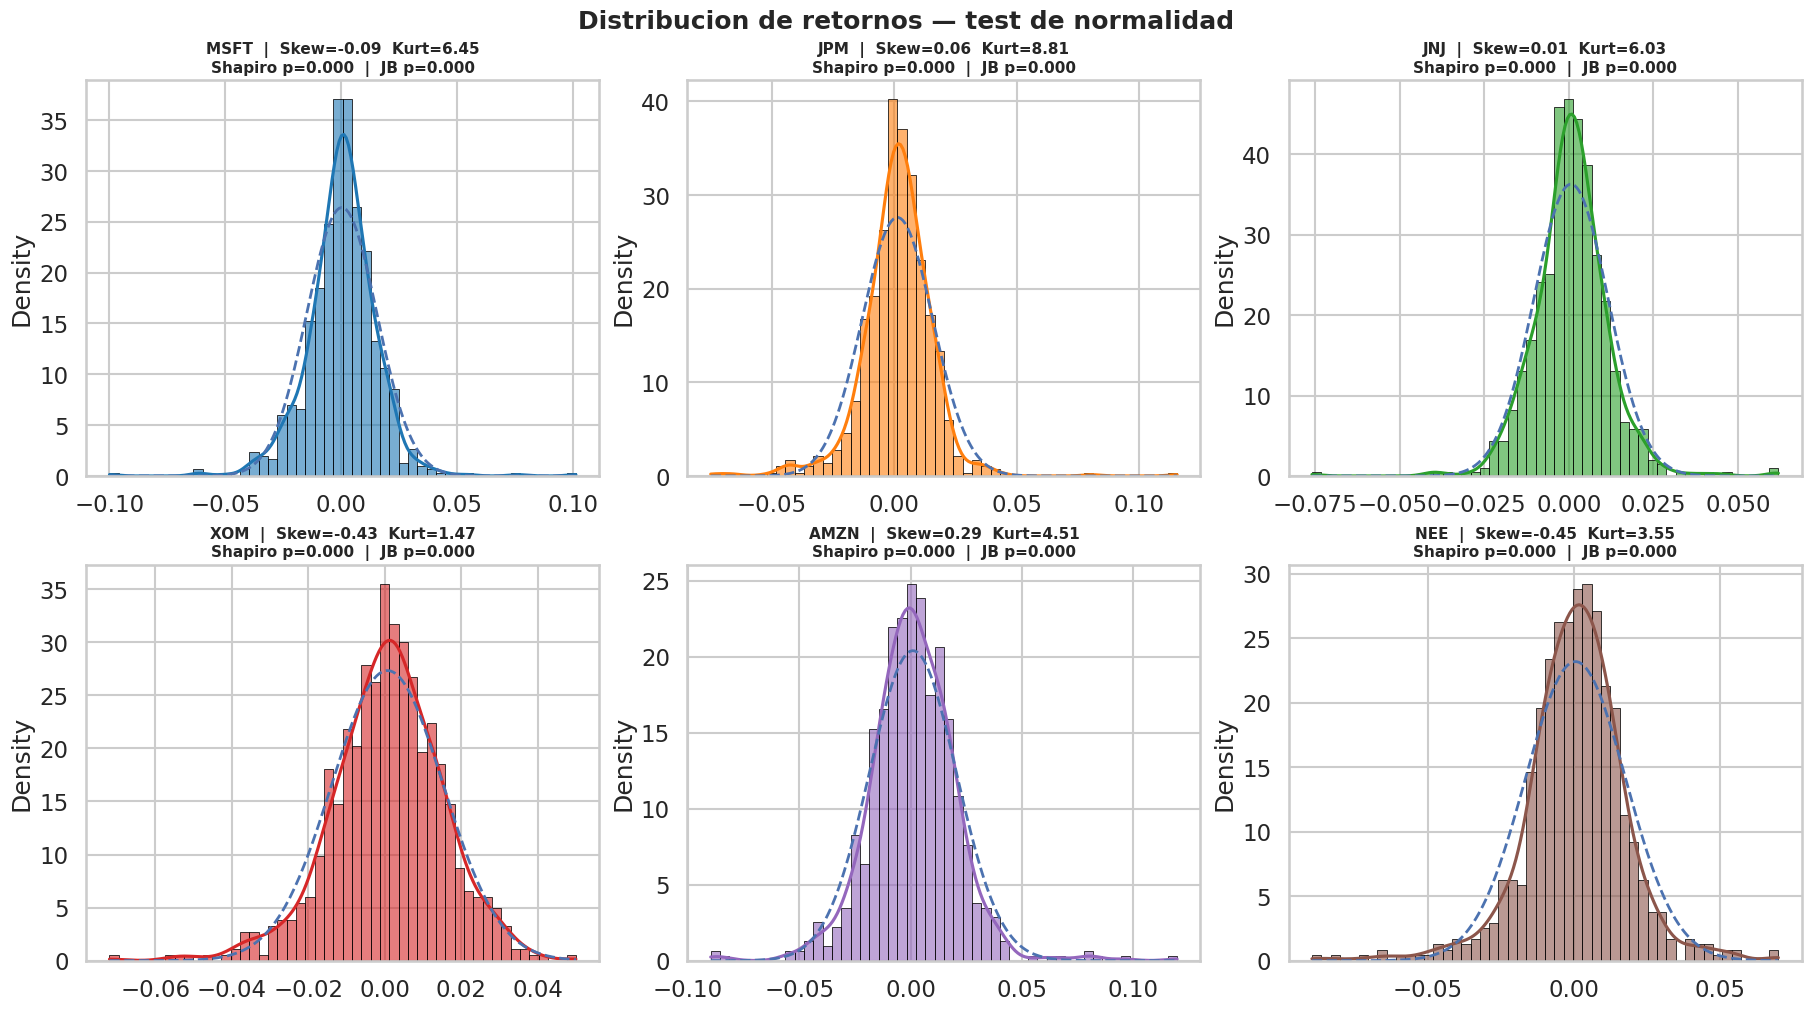


Activos que rechazan normalidad (JB p<0.05): 6/6
Con fat tails presentes, el intervalo ±1σ captura menos del 68% real de escenarios.


,Ticker,Skewness,Kurtosis_exc,JB_p,Normal_JB
0,MSFT,-0.094628,6.445860,7.400358e-279,False
1,JPM,0.055571,8.814604,0.000000e+00,False
2,JNJ,0.010251,6.034466,3.087671e-244,False
3,XOM,-0.425777,1.468720,6.120289e-20,False
4,AMZN,0.293714,4.508734,7.050832e-139,False
5,NEE,-0.451133,3.545633,3.813479e-90,False


In [7]:
sns.set_theme(style='whitegrid', context='talk')
n_assets = df_returns.shape[1]
n_cols = 3
n_rows = math.ceil(n_assets / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows), constrained_layout=True)
axes = axes.flatten()
palette = sns.color_palette('tab10', n_assets)
norm_results = []

for i, col in enumerate(df_returns.columns):
    ax   = axes[i]
    data = df_returns[col].dropna()

    sns.histplot(data, bins=50, kde=True, stat='density', ax=ax,
                 color=palette[i], edgecolor='black', alpha=0.6)

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), '--', lw=2, label='Normal teorica')

    _, shapiro_p = shapiro(data)
    _, jb_p      = jarque_bera(data)
    skew         = data.skew()
    kurt_exc     = data.kurt()  # curtosis en exceso (normal = 0)

    norm_results.append({
        'Ticker': col, 'Mean': mu, 'Std': sigma,
        'Skewness': skew, 'Kurtosis_exc': kurt_exc,
        'Shapiro_p': shapiro_p, 'JB_p': jb_p
    })

    ax.set_title(
        f'{col}  |  Skew={skew:.2f}  Kurt={kurt_exc:.2f}\n'
        f'Shapiro p={shapiro_p:.3f}  |  JB p={jb_p:.3f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('')
    ax.set_ylabel('Density')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribucion de retornos — test de normalidad', fontsize=18, fontweight='bold')
plt.show()

df_normalidad = pd.DataFrame(norm_results)
df_normalidad['Normal_JB'] = df_normalidad['JB_p'] > 0.05

n_no_normal = (~df_normalidad['Normal_JB']).sum()
print(f'\nActivos que rechazan normalidad (JB p<0.05): {n_no_normal}/{n_assets}')
if n_no_normal > 0:
    print('Con fat tails presentes, el intervalo ±1σ captura menos del 68% real de escenarios.')
df_normalidad[['Ticker', 'Skewness', 'Kurtosis_exc', 'JB_p', 'Normal_JB']]

## 5. Matriz de correlación

ρ < 0.5 entre pares → buena diversificación. Correlaciones altas (> 0.7) indican que dos activos se mueven casi en tándem — combinarlos aporta poco beneficio de diversificación y se puede considerar reducir exposición a uno de ellos.

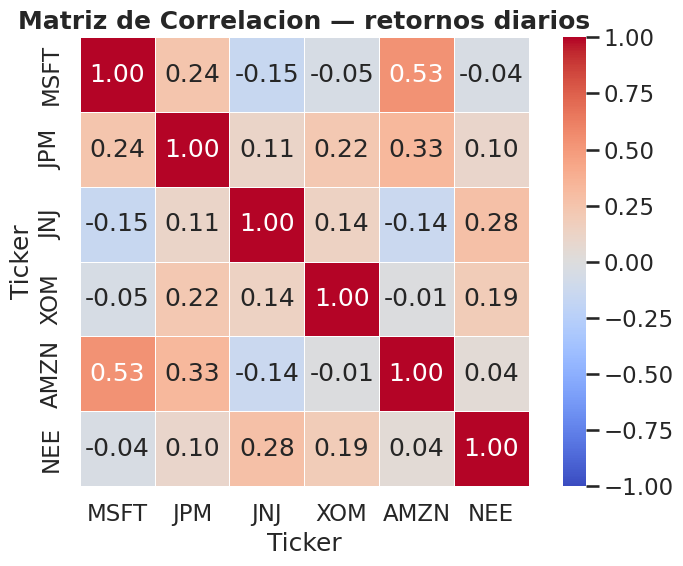

In [8]:
corr = df_returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlacion — retornos diarios', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Simulación Monte Carlo

Generamos 100.000 carteras con pesos aleatorios por activo. Los pesos son **dinámicos**: `min = 2%`, `max = max(20%, 2/n)` — permite más concentración con pocos activos y converge a 20% en n = 10. La función es **vectorizada**: opera sobre matrices en lugar de bucles Python → segundos en lugar de minutos.

**Métricas por cartera:**
- `R_cartera = Σ wᵢ·Rᵢ` (exacto con retornos simples — propiedad de agregabilidad cross-seccional)
- **Retorno anualizado**: `(1 + μ_diario)^h − 1` — compuesto geométrico. Preferible a `μ × h` (aritmético) porque no supone ausencia de compounding; la diferencia crece con h.
- **Volatilidad anualizada**: `σ_diario × √h` — regla de la raíz cuadrada del tiempo, asume retornos i.i.d.
- **Downside Deviation**: `√(E[min(r − Rf, 0)²]) × √h` — base del Sortino. Solo cuenta retornos negativos respecto a Rf; la volatilidad alcista no penaliza.
- **CVaR 95% ↓**: pérdida media en el peor 5% de días — **valor diario, sin escalar al horizonte**. Mide la intensidad del riesgo de cola bajista y es comparable entre carteras y horizontes.
- **CVaR 95% ↑**: ganancia media en el mejor 5% de días — **valor diario, sin escalar al horizonte**. **Uso correcto**: comparar el ratio CVaR↓/CVaR↑ para evaluar la asimetría de la distribución diaria — ratio > 1 indica días extremos bajistas más intensos que los alcistas. Reportar el CVaR diario lo hace directo de leer y comparable entre carteras, frente a versiones escaladas que conflactan un extremo de un solo día con el período entero.
- **Sharpe** = `(μ_h − Rf_h) / σ_h` — retorno en exceso por unidad de riesgo total.
- **Sortino** = `(μ_h − Rf_h) / DD_h` — retorno en exceso por unidad de riesgo **bajista**.

**Dos simulaciones independientes:** mismos datos históricos, distinto horizonte de escalado.

In [9]:
N_SIMULATIONS = 100_000

def weight_constraints(n):
    """Restricciones dinamicas: min 2%, max = max(20%, 2/n). Converge a 20% en n=10."""
    return 0.02, max(0.20, 2.0 / n)

def run_monte_carlo(df_ret, n_sim, horizon, rf_annual, seed=42, batch_size=10_000):
    """
    Monte Carlo vectorizado de carteras aleatorias.
    horizon : dias de trading (63=trimestral, 252=anual)
    rf_annual: tasa libre de riesgo anualizada
    """
    np.random.seed(seed)
    R   = df_ret.values
    T, n = R.shape
    min_w, max_w = weight_constraints(n)
    rf_daily = (1 + rf_annual) ** (1 / 252) - 1
    rf_h     = (1 + rf_annual) ** (horizon / 252) - 1
    k_tail   = max(1, int(0.05 * T))

    batches   = []
    generated = 0

    with tqdm(total=n_sim, desc=f'MC {horizon}d') as pbar:
        while generated < n_sim:
            need = min(batch_size, n_sim - generated)
            # Muestreo UNIFORME sobre la region factible {w_i in [min_w, max_w], sum w = 1}:
            #   1) Dirichlet(1,...,1) = uniforme sobre el simplex (normalizar exponenciales).
            #      Normalizar uniformes U(0,1) NO es uniforme: sesga los pesos hacia 1/n.
            #   2) Mapa afin  w = min_w + (1 - n*min_w)*v  impone el minimo SIN rechazo
            #      (biyeccion afin del simplex => preserva la uniformidad). Solo se rechaza
            #      el limite superior, lo que da mucha mas aceptacion que rechazar ambos.
            v    = np.random.exponential(size=(need * 8, n))
            v   /= v.sum(axis=1, keepdims=True)
            raw  = min_w + (1.0 - n * min_w) * v
            W    = raw[(raw <= max_w).all(axis=1)][:need]
            if len(W) == 0:
                continue

            P = R @ W.T                    # (T, k) retornos diarios de cada cartera

            mu_d    = P.mean(axis=0)
            sigma_d = P.std(axis=0)

            # Downside deviation: sqrt(E[min(r - Rf, 0)^2])
            excess = P - rf_daily
            dd_d   = np.sqrt((np.where(excess < 0, excess, 0) ** 2).mean(axis=0))

            # CVaR downside (peor 5%) y upside (mejor 5%)
            sorted_P  = np.sort(P, axis=0)
            cvar_d    = -sorted_P[:k_tail].mean(axis=0)   # downside: pérdida media
            cvar_up_d =  sorted_P[-k_tail:].mean(axis=0)  # upside: ganancia media

            # Anualización al horizonte (regla de la raíz del tiempo)
            mu_h     = (1 + mu_d)   ** horizon - 1   # geométrico
            sigma_h  = sigma_d  * np.sqrt(horizon)
            dd_h     = dd_d     * np.sqrt(horizon)
            # CVaR se reporta DIARIO (sin escalar al horizonte) — ver glosario del README.

            sharpe  = (mu_h - rf_h) / np.where(sigma_h > 0, sigma_h, np.nan)
            sortino = (mu_h - rf_h) / np.where(dd_h   > 0, dd_h,    np.nan)

            b = pd.DataFrame(W, columns=[f'Peso_{c}' for c in df_ret.columns])
            b['Retorno']      = mu_h
            b['Volatilidad']  = sigma_h
            b['CVaR_95']      = cvar_d     # diario (sin escalar al horizonte)
            b['CVaR_95_up']   = cvar_up_d  # diario (sin escalar al horizonte)
            b['Sharpe']       = sharpe
            b['Sortino']      = sortino

            batches.append(b)
            generated += len(W)
            pbar.update(len(W))

    return pd.concat(batches, ignore_index=True).iloc[:n_sim]

In [11]:
rf_q = (1 + RF_ANNUAL) ** (63  / 252) - 1   # Rf trimestral
df_q = run_monte_carlo(df_returns, N_SIMULATIONS, horizon=63,  rf_annual=RF_ANNUAL, seed=42)
print('Trimestral OK:', df_q.shape)

MC 63d: 100%|██████████| 100000/100000 [00:05<00:00, 17351.88it/s]

Trimestral OK: (100000, 12)


In [12]:
rf_a = RF_ANNUAL                             # Rf ya esta en escala anual
df_a = run_monte_carlo(df_returns, N_SIMULATIONS, horizon=252, rf_annual=RF_ANNUAL, seed=42)
print('Anual OK:', df_a.shape)

MC 252d: 100%|██████████| 100000/100000 [00:06<00:00, 15867.64it/s]

Anual OK: (100000, 12)


## 7. Carteras óptimas

Para cada horizonte identificamos tres carteras clave del espacio de la frontera eficiente:
- **Mínima volatilidad**: menor riesgo absoluto (σ). Preferida cuando se busca preservación de capital — es el vértice izquierdo de la frontera.
- **Máximo Sharpe**: mejor retorno por unidad de riesgo total. Punto tangente de la línea del mercado de capitales (CML) con la frontera eficiente.
- **Máximo Sortino**: mejor retorno por unidad de riesgo **bajista**. Más apropiado que el Sharpe cuando la distribución tiene asimetría negativa (skewness < 0) — los crashes son más extremos que los rallies de igual probabilidad.

In [13]:
peso_cols   = [c for c in df_q.columns if c.startswith('Peso_')]
ticker_list = [c.replace('Peso_', '') for c in peso_cols]

def resumen_optimas(df, horizon, rf_h, label):
    idx_vol     = df['Volatilidad'].idxmin()
    idx_sharpe  = df['Sharpe'].idxmax()
    idx_sortino = df['Sortino'].idxmax()

    print(f'\n{"="*70}')
    print(f'HORIZONTE {label} ({horizon}d)   |   Rf={rf_h*100:.2f}%')
    print(f'{"="*70}')
    for nombre, idx in [('Min Volatilidad', idx_vol),
                        ('Max Sharpe',      idx_sharpe),
                        ('Max Sortino',     idx_sortino)]:
        row = df.loc[idx]
        print(f'\n  [{nombre}]')
        print(f'    Retorno:      {row["Retorno"]*100:.2f}%')
        print(f'    Volatilidad:  {row["Volatilidad"]*100:.2f}%')
        print(f'    CVaR 95% ↓:   {row["CVaR_95"]*100:.2f}%')
        print(f'    CVaR 95% ↑:   {row["CVaR_95_up"]*100:.2f}%')
        print(f'    Sharpe:       {row["Sharpe"]:.3f}')
        print(f'    Sortino:      {row["Sortino"]:.3f}')
        pesos = {t: row[f'Peso_{t}']*100 for t in ticker_list}
        print(f'    Pesos: ' + '  '.join([f'{t}={v:.1f}%' for t, v in pesos.items()]))

resumen_optimas(df_q, 63,  rf_q, 'TRIMESTRAL')
resumen_optimas(df_a, 252, rf_a, 'ANUAL')


HORIZONTE TRIMESTRAL (63d)   |   Rf=0.90%

  [Min Volatilidad]
    Retorno:      4.06%
    Volatilidad:  5.69%
    CVaR 95% ↓:   1.57%
    CVaR 95% ↑:   1.53%
    Sharpe:       0.556
    Sortino:      0.804
    Pesos: MSFT=25.8%  JPM=10.7%  JNJ=33.1%  XOM=19.2%  AMZN=2.2%  NEE=9.1%

  [Max Sharpe]
    Retorno:      6.01%
    Volatilidad:  6.64%
    CVaR 95% ↓:   1.87%
    CVaR 95% ↑:   1.87%
    Sharpe:       0.770
    Sortino:      1.140
    Pesos: MSFT=3.1%  JPM=30.9%  JNJ=32.2%  XOM=12.1%  AMZN=19.1%  NEE=2.6%

  [Max Sortino]
    Retorno:      6.01%
    Volatilidad:  6.64%
    CVaR 95% ↓:   1.87%
    CVaR 95% ↑:   1.87%
    Sharpe:       0.770
    Sortino:      1.140
    Pesos: MSFT=3.1%  JPM=30.9%  JNJ=32.2%  XOM=12.1%  AMZN=19.1%  NEE=2.6%

HORIZONTE ANUAL (252d)   |   Rf=3.63%

  [Min Volatilidad]
    Retorno:      17.24%
    Volatilidad:  11.38%
    CVaR 95% ↓:   1.57%
    CVaR 95% ↑:   1.53%
    Sharpe:       1.196
    Sortino:      1.731
    Pesos: MSFT=25.8%  JPM=10.7%  JNJ

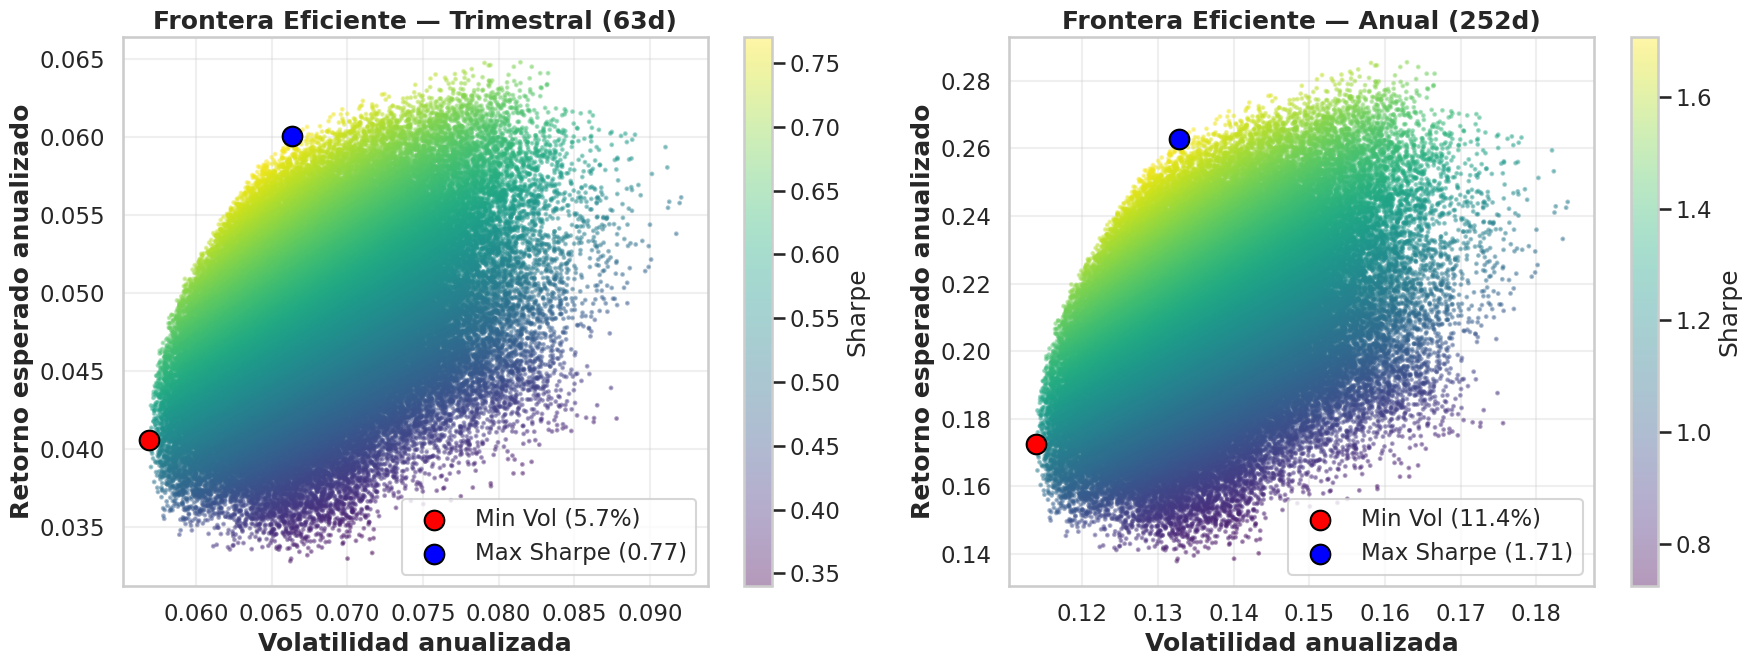

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, df, rf_h, horizon, label in [
    (axes[0], df_q, rf_q, 63,  'Trimestral (63d)'),
    (axes[1], df_a, rf_a, 252, 'Anual (252d)')
]:
    sc = ax.scatter(
        df['Volatilidad'], df['Retorno'],
        c=df['Sharpe'], cmap='viridis', alpha=0.4, s=4
    )

    # Min vol
    idx_v = df['Volatilidad'].idxmin()
    ax.scatter(df.loc[idx_v, 'Volatilidad'], df.loc[idx_v, 'Retorno'],
               color='red', s=200, edgecolor='black', zorder=5,
               label=f'Min Vol ({df.loc[idx_v,"Volatilidad"]*100:.1f}%)')

    # Max Sharpe
    idx_s = df['Sharpe'].idxmax()
    ax.scatter(df.loc[idx_s, 'Volatilidad'], df.loc[idx_s, 'Retorno'],
               color='blue', s=200, edgecolor='black', zorder=5,
               label=f'Max Sharpe ({df.loc[idx_s, "Sharpe"]:.2f})')

    plt.colorbar(sc, ax=ax, label='Sharpe')
    ax.set_xlabel('Volatilidad anualizada', fontweight='bold')
    ax.set_ylabel('Retorno esperado anualizado', fontweight='bold')
    ax.set_title(f'Frontera Eficiente — {label}', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Optimización exacta — scipy

El Monte Carlo encuentra el *mejor de 100.000 muestras aleatorias*, no el óptimo matemático. Con `scipy.optimize.minimize` (método SLSQP) resolvemos analíticamente **tres carteras óptimas** por horizonte:

| Cartera | Objetivo | Cuándo usarla |
|---------|----------|---------------|
| **Min Volatilidad** | minimizar σ | Preservación de capital, perfil conservador |
| **Max Sharpe** | maximizar (μ−Rf)/σ | Retorno por unidad de riesgo total; asume distribución simétrica |
| **Max Sortino** | maximizar (μ−Rf)/DD_bajista | Retorno por unidad de riesgo **a la baja**; más apropiado cuando skewness < 0 |

Si Max Sharpe y Max Sortino convergen (diferencia de pesos < 5pp): la distribución es casi simétrica, ambas son equivalentes.  
Si divergen: la asimetría es relevante y Sortino es la elección correcta para quien prioriza protección frente a caídas extremas.

In [15]:
R_mat = df_returns.values
n     = R_mat.shape[1]
bounds      = [(0.02, 0.20)] * n
constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
w0 = np.ones(n) / n   # punto inicial: pesos iguales

def portf_stats(w, horizon, rf_h):
    r   = R_mat.dot(w)
    mu  = (1 + r.mean()) ** horizon - 1
    sig = r.std() * np.sqrt(horizon)
    return mu, sig

def neg_sharpe(w, horizon, rf_h):
    mu, sig = portf_stats(w, horizon, rf_h)
    return -(mu - rf_h) / sig

def neg_sortino(w, horizon, rf_h):
    r        = R_mat.dot(w)
    mu_h     = (1 + r.mean()) ** horizon - 1
    rf_daily = (1 + RF_ANNUAL) ** (1 / 252) - 1
    excess   = r - rf_daily
    dd_h     = np.sqrt((np.where(excess < 0, excess, 0) ** 2).mean()) * np.sqrt(horizon)
    if dd_h <= 0:
        return 0.0
    return -(mu_h - rf_h) / dd_h

def portf_vol(w, horizon):
    return R_mat.dot(w).std() * np.sqrt(horizon)

results_scipy = {}
for label, horizon, rf_h in [('Q', 63, rf_q), ('A', 252, rf_a)]:
    opt_sharpe  = minimize(neg_sharpe,  w0, args=(horizon, rf_h), method='SLSQP', bounds=bounds, constraints=constraints)
    opt_sortino = minimize(neg_sortino, w0, args=(horizon, rf_h), method='SLSQP', bounds=bounds, constraints=constraints)
    opt_vol     = minimize(portf_vol,   w0, args=(horizon,),      method='SLSQP', bounds=bounds, constraints=constraints)
    results_scipy[label] = {
        'sharpe': opt_sharpe, 'sortino': opt_sortino, 'vol': opt_vol,
        'horizon': horizon, 'rf_h': rf_h
    }

print(f'{"="*65}')
for label, res in results_scipy.items():
    h, rf_h = res['horizon'], res['rf_h']
    lbl = 'TRIMESTRAL' if label == 'Q' else 'ANUAL'
    for tipo, opt in [('Max Sharpe', res['sharpe']), ('Max Sortino', res['sortino']), ('Min Vol', res['vol'])]:
        w   = opt.x
        mu, sig = portf_stats(w, h, rf_h)
        sr  = (mu - rf_h) / sig
        print(f'\n[{lbl} — {tipo}]')
        print(f'  Retorno: {mu*100:.2f}%  |  Vol: {sig*100:.2f}%  |  Sharpe: {sr:.3f}')
        for t, wi in zip(ticker_list, w):
            print(f'    {t:6s}: {wi*100:.1f}%')

# Carteras de referencia trimestral (scipy — exactas)
w_ref_sharpe  = results_scipy['Q']['sharpe'].x
w_ref_sortino = results_scipy['Q']['sortino'].x


[TRIMESTRAL — Max Sharpe]
  Retorno: 5.32%  |  Vol: 6.48%  |  Sharpe: 0.683
    MSFT  : 7.3%
    JPM   : 20.0%
    JNJ   : 20.0%
    XOM   : 20.0%
    AMZN  : 20.0%
    NEE   : 12.7%

[TRIMESTRAL — Max Sortino]
  Retorno: 5.31%  |  Vol: 6.47%  |  Sharpe: 0.683
    MSFT  : 8.2%
    JPM   : 20.0%
    JNJ   : 20.0%
    XOM   : 20.0%
    AMZN  : 20.0%
    NEE   : 11.8%

[TRIMESTRAL — Min Vol]
  Retorno: 4.52%  |  Vol: 6.04%  |  Sharpe: 0.599
    MSFT  : 20.0%
    JPM   : 17.0%
    JNJ   : 20.0%
    XOM   : 20.0%
    AMZN  : 7.0%
    NEE   : 16.0%

[ANUAL — Max Sharpe]
  Retorno: 23.06%  |  Vol: 12.97%  |  Sharpe: 1.498
    MSFT  : 7.2%
    JPM   : 20.0%
    JNJ   : 20.0%
    XOM   : 20.0%
    AMZN  : 20.0%
    NEE   : 12.8%

[ANUAL — Max Sortino]
  Retorno: 23.02%  |  Vol: 12.95%  |  Sharpe: 1.497
    MSFT  : 8.1%
    JPM   : 20.0%
    JNJ   : 20.0%
    XOM   : 20.0%
    AMZN  : 20.0%
    NEE   : 11.9%

[ANUAL — Min Vol]
  Retorno: 19.36%  |  Vol: 12.09%  |  Sharpe: 1.302
    MSFT  : 20.0

## 9. Sugerencias — análisis de resultados

Sugerencias generadas automáticamente a partir del análisis anterior. Sirven como punto de partida para la toma de decisiones; no son recomendaciones de inversión.

In [16]:
suggestions = []

# --- Correlaciones altas ---
for i in range(len(ticker_list)):
    for j in range(i + 1, len(ticker_list)):
        rho = corr.iloc[i, j]
        if abs(rho) > 0.65:
            suggestions.append(
                f'[DIVERSIF] Alta correlacion {ticker_list[i]}-{ticker_list[j]} '
                f'(rho={rho:.2f}). Poco beneficio de combinarlos; considera sustituir uno.'
            )

# --- Fat tails / asimetria por activo ---
for _, row in df_normalidad.iterrows():
    if not row['Normal_JB']:
        tail = 'cola izquierda' if row['Skewness'] < -0.3 else 'distribucion no normal'
        suggestions.append(
            f'[RIESGO COLA] {row["Ticker"]}: {tail} '
            f'(Skew={row["Skewness"]:.2f}, Kurt_exc={row["Kurtosis_exc"]:.2f}). '
            f'El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.'
        )

# --- Comparacion Max Sharpe vs Max Sortino (trimestral, scipy) ---
w_sh = results_scipy['Q']['sharpe'].x
w_so = results_scipy['Q']['sortino'].x
diffs_pp = np.abs(w_sh - w_so) * 100
max_diff = diffs_pp.max()
main_diff_ticker = ticker_list[diffs_pp.argmax()]
if max_diff > 5.0:
    suggestions.append(
        f'[SHARPE vs SORTINO] Carteras divergen '
        f'(mayor diferencia en {main_diff_ticker}: {max_diff:.1f}pp). '
        f'La asimetria bajista es relevante — usa Max Sortino si priorizas '
        f'proteccion frente a caidas extremas.'
    )
else:
    suggestions.append(
        f'[SHARPE vs SORTINO] Carteras casi identicas '
        f'(diferencia maxima: {max_diff:.1f}pp en {main_diff_ticker}). '
        f'Distribucion aproximadamente simetrica — ambas optimizaciones son robustas.'
    )

# --- Perfil bajista ---
best_q = df_q.loc[df_q['Sharpe'].idxmax()]
if best_q['Sharpe'] > 0:
    ratio_ss = best_q['Sortino'] / best_q['Sharpe']
    if ratio_ss > 1.3:
        suggestions.append(
            f'[PERFIL BAJISTA] Sortino/Sharpe = {ratio_ss:.2f}x en cartera optima trimestral. '
            f'La mayor parte de la volatilidad es alcista — buen perfil de riesgo.'
        )

# --- Entorno de tipos ---
if RF_ANNUAL > 0.04:
    suggestions.append(
        f'[ENTORNO] Rf={RF_ANNUAL*100:.1f}% (T-Bill 3M). '
        f'Con tipos altos el Sharpe se contrae — verificar que el retorno justifica el riesgo.'
    )
elif RF_ANNUAL < 0.02:
    suggestions.append(
        f'[ENTORNO] Rf={RF_ANNUAL*100:.1f}% muy baja. '
        f'El Sharpe puede resultar inflado comparado con periodos de tipos altos.'
    )

print('SUGERENCIAS DEL ANALISIS')
print('=' * 70)
for i, s in enumerate(suggestions, 1):
    print(f'{i}. {s}')
    print()

SUGERENCIAS DEL ANALISIS
1. [RIESGO COLA] MSFT: distribucion no normal (Skew=-0.09, Kurt_exc=6.45). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

2. [RIESGO COLA] JPM: distribucion no normal (Skew=0.06, Kurt_exc=8.81). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

3. [RIESGO COLA] JNJ: distribucion no normal (Skew=0.01, Kurt_exc=6.03). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

4. [RIESGO COLA] XOM: cola izquierda (Skew=-0.43, Kurt_exc=1.47). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

5. [RIESGO COLA] AMZN: distribucion no normal (Skew=0.29, Kurt_exc=4.51). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

6. [RIESGO COLA] NEE: cola izquierda (Skew=-0.45, Kurt_exc=3.55). El CVaR↓ vs CVaR↑ revela la asimetria real de la distribucion.

7. [SHARPE vs SORTINO] Carteras casi identicas (diferencia maxima: 0.9pp en NEE). Distribucion aproximadamente simetrica — ambas optimizaciones son robustas.

8. [P

CARTERAS DE REFERENCIA — Horizonte Trimestral (scipy)
Metrica                         Max Sharpe     Max Sortino
------------------------------------------------------------
Retorno trimestral                   5.32%           5.31%
Volatilidad                          6.48%           6.47%
CVaR 95% ↓ (downside)                1.85%           1.85%
CVaR 95% ↑ (upside)                  1.75%           1.75%
Sharpe                               0.683           0.683
Sortino                              0.991           0.991

Ticker     Max Sharpe    Max Sortino     Diferencia
----------------------------------------------------
MSFT             7.3%           8.2%   ▲       0.9pp
JPM             20.0%          20.0%           0.0pp
JNJ             20.0%          20.0%           0.0pp
XOM             20.0%          20.0%           0.0pp
AMZN            20.0%          20.0%           0.0pp
NEE             12.7%          11.8%   ▼       0.9pp


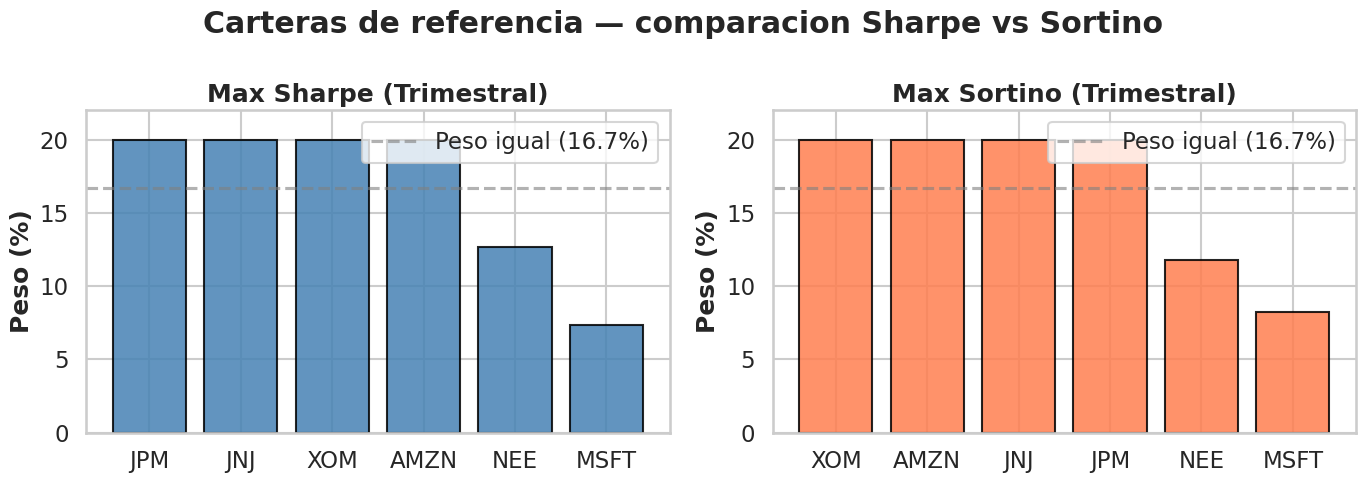

In [17]:
def full_portf_metrics(w, horizon, rf_h):
    """Calcula todas las metricas de una cartera dado un vector de pesos."""
    r        = R_mat.dot(w)
    mu_h     = (1 + r.mean()) ** horizon - 1
    sig_h    = r.std() * np.sqrt(horizon)
    rf_daily = (1 + RF_ANNUAL) ** (1 / 252) - 1
    excess   = r - rf_daily
    dd_h     = np.sqrt((np.where(excess < 0, excess, 0) ** 2).mean()) * np.sqrt(horizon)
    k_tail   = max(1, int(0.05 * len(r)))
    sorted_r = np.sort(r)
    cvar_d    = -sorted_r[:k_tail].mean()    # downside: peor 5% — DIARIO (sin escalar)
    cvar_up_d =  sorted_r[-k_tail:].mean()   # upside: mejor 5% — DIARIO (sin escalar)
    return {
        'mu':      mu_h,
        'sig':     sig_h,
        'cvar':    cvar_d,
        'cvar_up': cvar_up_d,
        'sharpe':  (mu_h - rf_h) / sig_h,
        'sortino': (mu_h - rf_h) / dd_h if dd_h > 0 else np.nan,
    }

m_sh = full_portf_metrics(w_ref_sharpe,  63, rf_q)
m_so = full_portf_metrics(w_ref_sortino, 63, rf_q)

# --- Tabla comparativa de metricas ---
print(f'CARTERAS DE REFERENCIA — Horizonte Trimestral (scipy)\n{"="*60}')
print(f'{"Metrica":28s} {"Max Sharpe":>13s}   {"Max Sortino":>13s}')
print('-' * 60)
for label, key, fmt_str in [
    ('Retorno trimestral',    'mu',      '{:>12.2f}%'),
    ('Volatilidad',           'sig',     '{:>12.2f}%'),
    ('CVaR 95% ↓ (downside)', 'cvar',    '{:>12.2f}%'),
    ('CVaR 95% ↑ (upside)',   'cvar_up', '{:>12.2f}%'),
    ('Sharpe',                'sharpe',  '{:>13.3f}'),
    ('Sortino',               'sortino', '{:>13.3f}'),
]:
    mult = 100 if key in ('mu', 'sig', 'cvar', 'cvar_up') else 1
    v_sh = fmt_str.format(m_sh[key] * mult)
    v_so = fmt_str.format(m_so[key] * mult)
    print(f'{label:28s} {v_sh}   {v_so}')

# --- Tabla de pesos con diferencia ---
print(f'\n{"Ticker":8s} {"Max Sharpe":>12s}   {"Max Sortino":>12s}   {"Diferencia":>12s}')
print('-' * 52)
for t, ws, wso in zip(ticker_list, w_ref_sharpe, w_ref_sortino):
    diff  = (wso - ws) * 100
    arrow = '▲' if diff > 0.5 else ('▼' if diff < -0.5 else ' ')
    print(f'{t:8s} {ws*100:>11.1f}%   {wso*100:>11.1f}%   {arrow}{abs(diff):>10.1f}pp')

# --- Visualizacion lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, w_ref, title, color in [
    (axes[0], w_ref_sharpe,  'Max Sharpe (Trimestral)',  'steelblue'),
    (axes[1], w_ref_sortino, 'Max Sortino (Trimestral)', 'coral'),
]:
    sorted_pairs = sorted(zip(ticker_list, w_ref), key=lambda x: -x[1])
    ticks_s, weights_s = zip(*sorted_pairs)
    ax.bar(ticks_s, [wi * 100 for wi in weights_s], color=color, edgecolor='black', alpha=0.85)
    ax.axhline(100 / len(ticker_list), color='gray', linestyle='--', alpha=0.6,
               label=f'Peso igual ({100/len(ticker_list):.1f}%)')
    ax.set_ylabel('Peso (%)', fontweight='bold')
    ax.set_ylim(0, 22)
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Carteras de referencia — comparacion Sharpe vs Sortino', fontweight='bold')
plt.tight_layout()
plt.show()